In [1]:
"""
Phase 4: Churn Prediction Models

Goal: Build and compare predictive models against the SQL scorecard
baseline (29x separation between Critical and Low tiers).
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

import xgboost as xgb
import shap

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
warnings.filterwarnings('ignore', category=FutureWarning)

# Seaborn styling
sns.set_style("whitegrid")
sns.set_palette("husl")

print("Imports complete.")
print(f"pandas {pd.__version__}, scikit-learn (check), xgboost {xgb.__version__}")

Imports complete.
pandas 3.0.3, scikit-learn (check), xgboost 3.2.0


In [2]:
# Load DB credentials from .env (same as ETL script)
load_dotenv('../.env')  # .env is in the project root, one level up

DB_USER = os.getenv("POSTGRES_USER")
DB_PASS = quote_plus(os.getenv("POSTGRES_PASSWORD"))
DB_HOST = os.getenv("POSTGRES_HOST")
DB_PORT = os.getenv("POSTGRES_PORT")
DB_NAME = os.getenv("POSTGRES_DB")

connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

# Test the connection
with engine.connect() as conn:
    result = pd.read_sql("SELECT COUNT(*) AS n FROM customers", conn)
    print(f"✓ Connected to PostgreSQL — {result['n'][0]:,} customers in database")

✓ Connected to PostgreSQL — 7,043 customers in database


In [3]:
# Pull the full modeling dataset by joining the 5 normalized tables
modeling_query = """
SELECT
    c.customer_id,

    -- Demographics
    c.gender,
    c.senior_citizen,
    c.has_partner,
    c.has_dependents,

    -- Subscription
    sub.tenure_months,
    sub.contract_type,
    sub.paperless_billing,
    sub.payment_method,

    -- Services
    s.phone_service,
    s.multiple_lines,
    s.internet_service,
    s.online_security,
    s.online_backup,
    s.device_protection,
    s.tech_support,
    s.streaming_tv,
    s.streaming_movies,

    -- Billing
    b.monthly_charges,
    b.total_charges,

    -- Target
    cs.churned
FROM       customers     c
JOIN       subscriptions sub ON c.customer_id = sub.customer_id
JOIN       services      s   ON c.customer_id = s.customer_id
JOIN       billing       b   ON c.customer_id = b.customer_id
JOIN       churn_status  cs  ON c.customer_id = cs.customer_id;
"""

df = pd.read_sql(modeling_query, engine)

print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {df['churned'].mean():.1%}")
print(f"\nColumn data types:")
print(df.dtypes)

Dataset shape: (7043, 21)
Churn rate: 26.5%

Column data types:
customer_id              str
gender                   str
senior_citizen          bool
has_partner             bool
has_dependents          bool
tenure_months          int64
contract_type            str
paperless_billing       bool
payment_method           str
phone_service           bool
multiple_lines           str
internet_service         str
online_security          str
online_backup            str
device_protection        str
tech_support             str
streaming_tv             str
streaming_movies         str
monthly_charges      float64
total_charges        float64
churned                 bool
dtype: object


In [4]:
# Verify the data matches our SQL findings
print("Churn rate by contract type (sanity check vs SQL):")
print(df.groupby('contract_type')['churned'].agg(['count', 'sum', 'mean']))

Churn rate by contract type (sanity check vs SQL):
                count   sum      mean
contract_type                        
Month-to-month   3875  1655  0.427097
One year         1473   166  0.112695
Two year         1695    48  0.028319


In [5]:
# Separate target from features
y = df['churned'].astype(int)  # convert bool to 0/1 for sklearn

# Drop the target and the ID column from features
X = df.drop(columns=['churned', 'customer_id'])

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nClass balance:")
print(y.value_counts(normalize=True).rename({0: 'Retained', 1: 'Churned'}).apply(lambda x: f"{x:.1%}"))

Feature matrix X shape: (7043, 19)
Target vector y shape: (7043,)

Class balance:
churned
Retained    73.5%
Churned     26.5%
Name: proportion, dtype: str


In [6]:
# Identify categorical (string) columns that need encoding
categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Categorical columns to encode ({len(categorical_cols)}):")
for col in categorical_cols:
    n_unique = X[col].nunique()
    print(f"  {col:20} ({n_unique} unique values)")

# One-hot encode them, dropping the first category of each to avoid
# multicollinearity (the "dummy variable trap")
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nBefore encoding: {X.shape[1]} features")
print(f"After encoding:  {X_encoded.shape[1]} features")
print(f"\nFirst few new columns: {X_encoded.columns.tolist()[:5]}")

Categorical columns to encode (11):
  gender               (2 unique values)
  contract_type        (3 unique values)
  payment_method       (4 unique values)
  multiple_lines       (3 unique values)
  internet_service     (3 unique values)
  online_security      (3 unique values)
  online_backup        (3 unique values)
  device_protection    (3 unique values)
  tech_support         (3 unique values)
  streaming_tv         (3 unique values)
  streaming_movies     (3 unique values)

Before encoding: 19 features
After encoding:  30 features

First few new columns: ['senior_citizen', 'has_partner', 'has_dependents', 'tenure_months', 'paperless_billing']


In [7]:
# Split into training and test sets
# - 80% train, 20% test
# - stratify=y preserves the 26.5% churn rate in both splits
# - random_state=42 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training set:  {X_train.shape[0]:,} customers ({X_train.shape[1]} features)")
print(f"Test set:      {X_test.shape[0]:,} customers")
print(f"\nTrain churn rate: {y_train.mean():.1%}")
print(f"Test churn rate:  {y_test.mean():.1%}")
print(f"(should both be ~26.5%, confirming stratification worked)")

Training set:  5,634 customers (30 features)
Test set:      1,409 customers

Train churn rate: 26.5%
Test churn rate:  26.5%
(should both be ~26.5%, confirming stratification worked)


In [8]:
# Logistic Regression is sensitive to feature scale — a feature ranging
# 0-100 will dominate one ranging 0-1. We scale numeric features to have
# mean=0, std=1.
#
# Tree-based models (Random Forest, XGBoost) are scale-invariant and
# don't need this step, but it doesn't hurt them either.

numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# IMPORTANT: fit the scaler on training data only, then apply to test.
# Fitting on test data would leak test set info into training (a subtle bug).
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print("Scaled feature summary (training set):")
print(X_train_scaled[numeric_cols].describe().round(3))

Scaled feature summary (training set):
       tenure_months  monthly_charges  total_charges
count       5634.000         5634.000       5634.000
mean           0.000            0.000         -0.000
std            1.000            1.000          1.000
min           -1.314           -1.537         -1.004
25%           -0.948           -0.967         -0.832
50%           -0.134            0.191         -0.391
75%            0.924            0.842          0.666
max            1.615            1.803          2.830


In [9]:
# Logistic Regression: interpretable baseline
# - solver='liblinear' handles small-to-medium datasets well
# - class_weight='balanced' adjusts for the 73.5/26.5 imbalance,
#   making the model pay equal attention to churners vs retainers
# - max_iter=1000 ensures convergence

logreg = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_scaled, y_train)

# Predict on the held-out test set
y_pred_lr      = logreg.predict(X_test_scaled)
y_proba_lr     = logreg.predict_proba(X_test_scaled)[:, 1]  # P(churn)

print("Logistic Regression trained.")
print(f"Coefficients learned: {logreg.coef_.shape[1]} features")

Logistic Regression trained.
Coefficients learned: 30 features


In [10]:
# For an imbalanced classification problem, accuracy alone is misleading.
# We care about THREE metrics:
#   - ROC-AUC: how well the model ranks churners above non-churners
#   - Precision-Recall AUC: more meaningful when positive class is rare
#   - Confusion matrix at default threshold (0.5)

print("=" * 60)
print("LOGISTIC REGRESSION — TEST SET PERFORMANCE")
print("=" * 60)

roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
pr_auc_lr  = average_precision_score(y_test, y_proba_lr)

print(f"\nROC-AUC:                {roc_auc_lr:.3f}")
print(f"Precision-Recall AUC:   {pr_auc_lr:.3f}")
print(f"\nClassification report at default threshold (0.5):")
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
print(f"Confusion matrix:")
print(f"              Predicted Retained   Predicted Churned")
print(f"Actual Retained        {cm[0,0]:>6,}              {cm[0,1]:>6,}")
print(f"Actual Churned         {cm[1,0]:>6,}              {cm[1,1]:>6,}")

LOGISTIC REGRESSION — TEST SET PERFORMANCE

ROC-AUC:                0.839
Precision-Recall AUC:   0.641

Classification report at default threshold (0.5):
              precision    recall  f1-score   support

    Retained       0.91      0.72      0.80      1035
     Churned       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

Confusion matrix:
              Predicted Retained   Predicted Churned
Actual Retained           747                 288
Actual Churned             75                 299


In [11]:
# Get coefficients with feature names
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': logreg.coef_[0],
})

# Convert coefficients to odds ratios for interpretability
# odds_ratio > 1 means feature INCREASES churn risk
# odds_ratio < 1 means feature DECREASES churn risk
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df['abs_coef']   = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).drop(columns='abs_coef')

print("TOP 10 FEATURES BY IMPACT (sorted by absolute coefficient strength):")
print("=" * 70)
print(coef_df.head(10).to_string(index=False))

print("\nINTERPRETATION:")
print("- odds_ratio > 1 means the feature INCREASES churn likelihood")
print("- odds_ratio < 1 means the feature DECREASES churn likelihood")

TOP 10 FEATURES BY IMPACT (sorted by absolute coefficient strength):
                        feature  coefficient  odds_ratio
         contract_type_Two year    -1.432614    0.238684
                  tenure_months    -1.304279    0.271368
   internet_service_Fiber optic     0.968324    2.633527
         contract_type_One year    -0.719130    0.487176
                  total_charges     0.609516    1.839541
                  phone_service    -0.487112    0.614398
payment_method_Electronic check     0.436493    1.547271
            online_security_Yes    -0.394065    0.674310
           streaming_movies_Yes     0.319441    1.376358
             multiple_lines_Yes     0.318647    1.375266

INTERPRETATION:
- odds_ratio > 1 means the feature INCREASES churn likelihood
- odds_ratio < 1 means the feature DECREASES churn likelihood


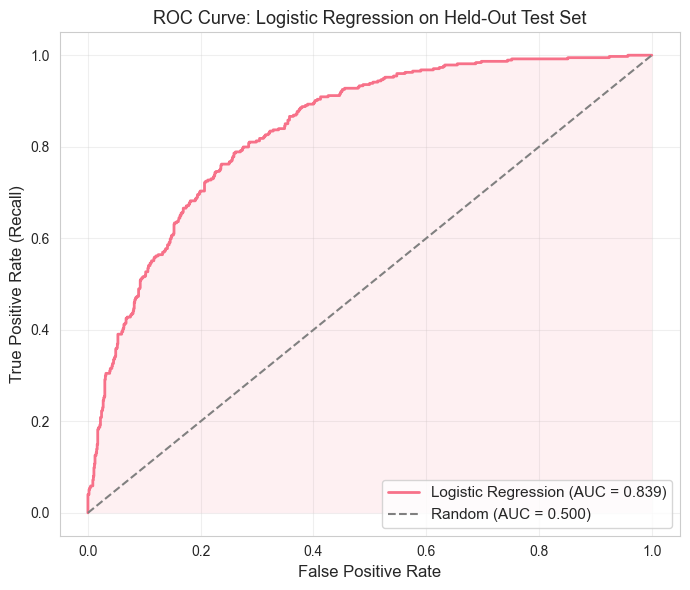

In [12]:
# Visualize how the model trades off true vs false positives across thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve: Logistic Regression on Held-Out Test Set', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Random Forest: an ensemble of decision trees
# - n_estimators=200 trees
# - class_weight='balanced' to handle the 26.5% churn rate
# - n_jobs=-1 uses all available CPU cores
# - max_depth=None lets each tree grow fully (we control overfitting via the ensemble)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Note: Random Forest doesn't need scaled features — it splits on raw values
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest trained.")
print(f"Number of trees: {rf.n_estimators}")
print(f"Number of features per tree split: {rf.n_features_in_}")

Random Forest trained.
Number of trees: 200
Number of features per tree split: 30


In [14]:
print("=" * 60)
print("RANDOM FOREST — TEST SET PERFORMANCE")
print("=" * 60)

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
pr_auc_rf  = average_precision_score(y_test, y_proba_rf)

print(f"\nROC-AUC:                {roc_auc_rf:.3f}")
print(f"Precision-Recall AUC:   {pr_auc_rf:.3f}")
print(f"\nClassification report at default threshold (0.5):")
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))

# Feature importance (different from logistic coefficients — these are Gini importance)
fi_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 features by importance:")
print(fi_rf.head(10).to_string(index=False))

RANDOM FOREST — TEST SET PERFORMANCE

ROC-AUC:                0.821
Precision-Recall AUC:   0.624

Classification report at default threshold (0.5):
              precision    recall  f1-score   support

    Retained       0.83      0.89      0.86      1035
     Churned       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Top 10 features by importance:
                        feature  importance
                  total_charges    0.180005
                  tenure_months    0.167688
                monthly_charges    0.150598
         contract_type_Two year    0.052545
   internet_service_Fiber optic    0.048911
payment_method_Electronic check    0.038978
         contract_type_One year    0.029033
            online_security_Yes    0.027260
                    gender_Male    0.025111
              paperless_billing    0.023450


In [15]:
# XGBoost: the standard for tabular competitions and many production systems
# - scale_pos_weight handles class imbalance (analogous to class_weight in sklearn)
# - we set conservative hyperparameters; full tuning could squeeze another 1-2%

# Compute scale_pos_weight from the training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (negative class / positive class): {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained.")

scale_pos_weight (negative class / positive class): 2.77
XGBoost trained.


In [16]:
print("=" * 60)
print("XGBOOST — TEST SET PERFORMANCE")
print("=" * 60)

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
pr_auc_xgb  = average_precision_score(y_test, y_proba_xgb)

print(f"\nROC-AUC:                {roc_auc_xgb:.3f}")
print(f"Precision-Recall AUC:   {pr_auc_xgb:.3f}")
print(f"\nClassification report at default threshold (0.5):")
print(classification_report(y_pred_xgb, y_test, target_names=['Retained', 'Churned']))

# XGBoost's feature importance
fi_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 features by importance:")
print(fi_xgb.head(10).to_string(index=False))

XGBOOST — TEST SET PERFORMANCE

ROC-AUC:                0.831
Precision-Recall AUC:   0.647

Classification report at default threshold (0.5):
              precision    recall  f1-score   support

    Retained       0.76      0.90      0.82       875
     Churned       0.76      0.53      0.63       534

    accuracy                           0.76      1409
   macro avg       0.76      0.71      0.72      1409
weighted avg       0.76      0.76      0.75      1409

Top 10 features by importance:
                        feature  importance
         contract_type_Two year    0.349193
         contract_type_One year    0.189680
   internet_service_Fiber optic    0.182095
            internet_service_No    0.052782
           streaming_movies_Yes    0.033807
                  tenure_months    0.017500
payment_method_Electronic check    0.015905
                  phone_service    0.014806
             multiple_lines_Yes    0.011564
            online_security_Yes    0.011424


              Model  ROC-AUC  PR-AUC  Recall (Churn)  Precision (Churn)
Logistic Regression    0.839   0.641           0.799              0.509
      Random Forest    0.821   0.624           0.505              0.630
            XGBoost    0.831   0.647           0.759              0.532


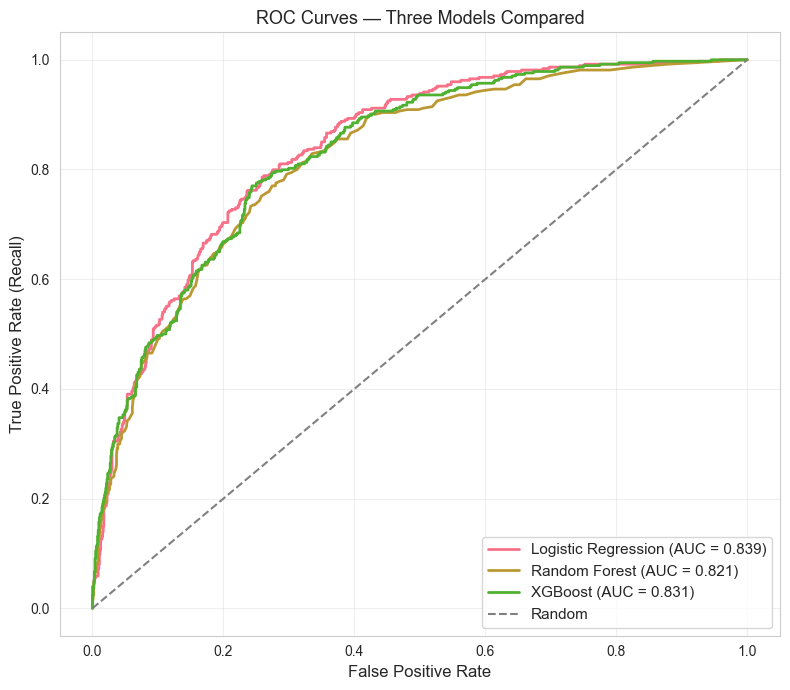

In [17]:
# Final comparison: which model wins?
results = pd.DataFrame({
    'Model':           ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC':         [roc_auc_lr, roc_auc_rf, roc_auc_xgb],
    'PR-AUC':          [pr_auc_lr, pr_auc_rf, pr_auc_xgb],
    'Recall (Churn)':  [
        confusion_matrix(y_test, y_pred_lr)[1,1] / confusion_matrix(y_test, y_pred_lr)[1].sum(),
        confusion_matrix(y_test, y_pred_rf)[1,1] / confusion_matrix(y_test, y_pred_rf)[1].sum(),
        confusion_matrix(y_test, y_pred_xgb)[1,1] / confusion_matrix(y_test, y_pred_xgb)[1].sum(),
    ],
    'Precision (Churn)': [
        confusion_matrix(y_test, y_pred_lr)[1,1] / confusion_matrix(y_test, y_pred_lr)[:,1].sum(),
        confusion_matrix(y_test, y_pred_rf)[1,1] / confusion_matrix(y_test, y_pred_rf)[:,1].sum(),
        confusion_matrix(y_test, y_pred_xgb)[1,1] / confusion_matrix(y_test, y_pred_xgb)[:,1].sum(),
    ],
})

results = results.round(3)
print(results.to_string(index=False))

# Plot all three ROC curves
plt.figure(figsize=(8, 7))

for model_name, y_proba, auc in [
    ('Logistic Regression', y_proba_lr,  roc_auc_lr),
    ('Random Forest',       y_proba_rf,  roc_auc_rf),
    ('XGBoost',             y_proba_xgb, roc_auc_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — Three Models Compared', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Cost-based threshold tuning
# Assumptions:
#   - Each retention offer costs $50 (discount, support call, etc.)
#   - Each churned customer represents $X in lost revenue
#     (we'll use their actual monthly_charges * 12)
# 
# We'll iterate through thresholds and find the one that
# maximizes net business value.

# Use the LogReg model since it won
y_proba = y_proba_lr

# Get the monthly charges for each test customer (for revenue calc)
test_charges = X_test['monthly_charges'].values

# Assumptions
RETENTION_OFFER_COST = 50      # $ per customer flagged
RETENTION_SUCCESS_RATE = 0.30  # 30% of saved customers actually stay
                               # (industry typical for retention campaigns)

results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    y_pred_t = (y_proba >= threshold).astype(int)

    # Confusion matrix elements
    tp = ((y_test == 1) & (y_pred_t == 1)).sum()  # correctly flagged churners
    fp = ((y_test == 0) & (y_pred_t == 1)).sum()  # wrongly flagged non-churners
    fn = ((y_test == 1) & (y_pred_t == 0)).sum()  # missed churners

    # Cost calculations
    # - Save: TP * retention_success_rate * annual revenue per saved customer
    # - Offer cost: (TP + FP) * cost per offer (we offer to everyone we flag)
    # - Missed: FN * annual revenue per missed customer (we lose them entirely)

    flagged = ((y_pred_t == 1))
    actually_churners_flagged = ((y_pred_t == 1) & (y_test == 1))

    # Revenue saved: 30% retention success on flagged true churners
    avg_annual_value = (test_charges[actually_churners_flagged] * 12).sum() * RETENTION_SUCCESS_RATE
    # Cost of offers
    offer_cost = flagged.sum() * RETENTION_OFFER_COST
    # Net business value
    net_value = avg_annual_value - offer_cost

    results.append({
        'threshold': threshold,
        'flagged':   flagged.sum(),
        'true_churners_caught': tp,
        'false_alarms':         fp,
        'missed_churners':      fn,
        'recall':               tp / (tp + fn) if (tp + fn) > 0 else 0,
        'revenue_saved':        avg_annual_value,
        'offer_cost':           offer_cost,
        'net_business_value':   net_value,
    })

results_df = pd.DataFrame(results).round(2)
print("Threshold tuning results:")
print(results_df.to_string(index=False))

# Find the optimal threshold
optimal_row = results_df.loc[results_df['net_business_value'].idxmax()]
print(f"\nOPTIMAL THRESHOLD: {optimal_row['threshold']:.2f}")
print(f"  Net business value: ${optimal_row['net_business_value']:,.0f}")
print(f"  Customers flagged:  {int(optimal_row['flagged']):,}")
print(f"  Recall achieved:    {optimal_row['recall']:.1%}")

Threshold tuning results:
 threshold  flagged  true_churners_caught  false_alarms  missed_churners  recall  revenue_saved  offer_cost  net_business_value
      0.10     1077                   367           710                7    0.98      101248.38       53850            47398.38
      0.15      987                   362           625               12    0.97       99616.50       49350            50266.50
      0.20      924                   357           567               17    0.95       97954.92       46200            51754.92
      0.25      863                   350           513               24    0.94       95743.62       43150            52593.62
      0.30      806                   343           463               31    0.92       94278.06       40300            53978.06
      0.35      753                   336           417               38    0.90       92925.72       37650            55275.72
      0.40      690                   321           369               53    0.

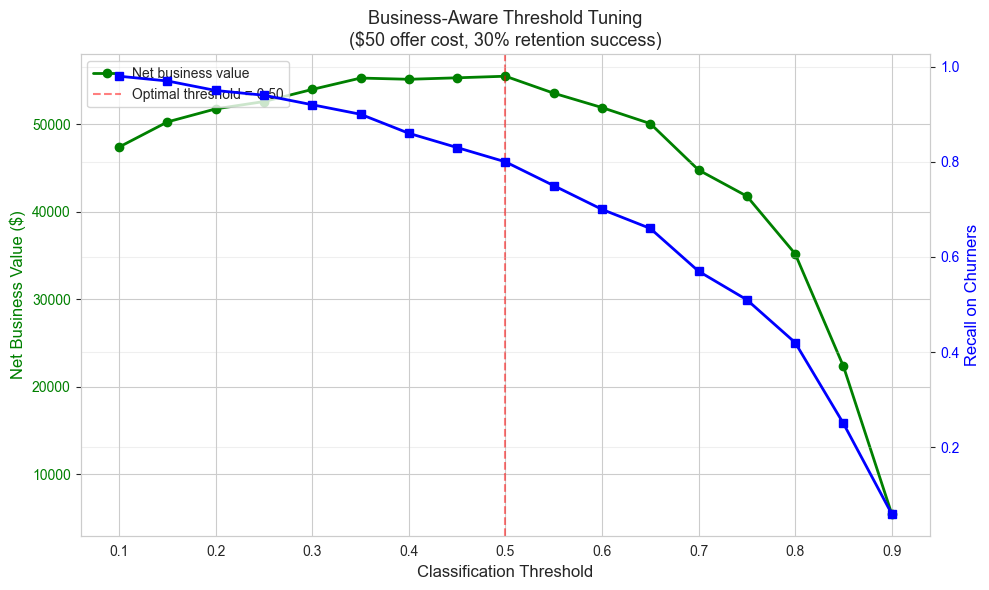

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(results_df['threshold'], results_df['net_business_value'], 
         color='green', linewidth=2, marker='o', label='Net business value')
ax1.set_xlabel('Classification Threshold', fontsize=12)
ax1.set_ylabel('Net Business Value ($)', fontsize=12, color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.axvline(optimal_row['threshold'], linestyle='--', color='red', alpha=0.5, 
            label=f"Optimal threshold = {optimal_row['threshold']:.2f}")
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(results_df['threshold'], results_df['recall'], 
         color='blue', linewidth=2, marker='s', label='Recall')
ax2.set_ylabel('Recall on Churners', fontsize=12, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Business-Aware Threshold Tuning\n($50 offer cost, 30% retention success)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# SHAP analysis on the Logistic Regression model
# We use the LogReg model because it won, but SHAP works on all 3.

import shap

# For logistic regression, LinearExplainer is fast and exact
explainer = shap.LinearExplainer(logreg, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values.shape}")
print("Each row is a customer, each column is a feature's contribution to that customer's prediction.")

SHAP values shape: (1409, 30)
Each row is a customer, each column is a feature's contribution to that customer's prediction.


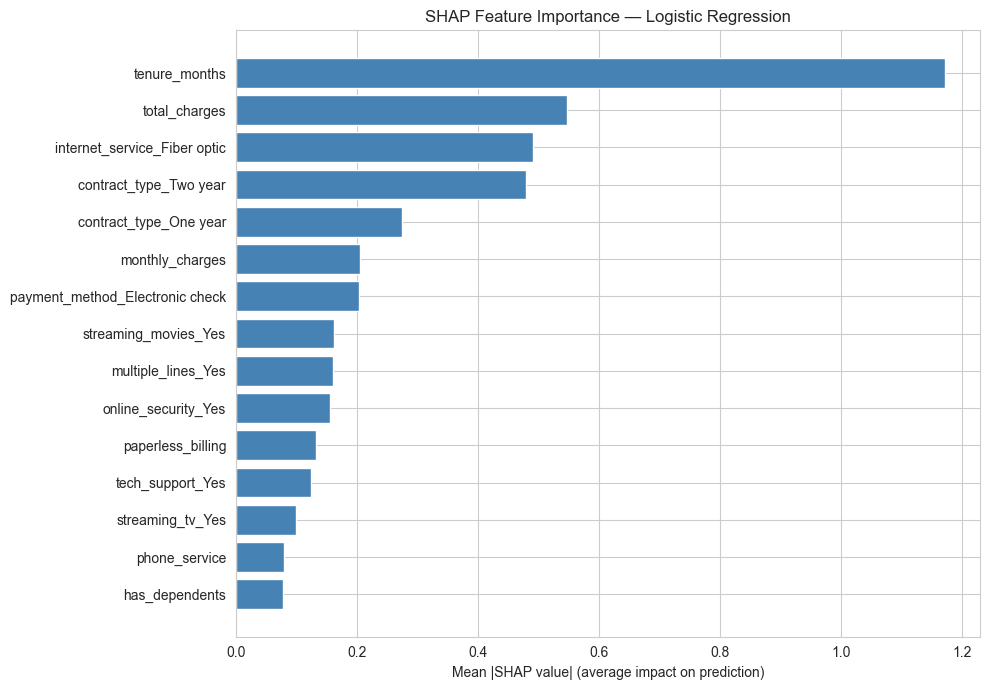

In [29]:
# Global feature importance: mean absolute SHAP value per feature
shap_np = np.asarray(shap_values, dtype=np.float64)
feature_names = X_test_scaled.columns.tolist()

importance = pd.DataFrame({
    'feature':     feature_names,
    'mean_abs_shap': np.abs(shap_np).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance['feature'], importance['mean_abs_shap'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value| (average impact on prediction)')
ax.set_title('SHAP Feature Importance — Logistic Regression')
plt.tight_layout()
plt.show()

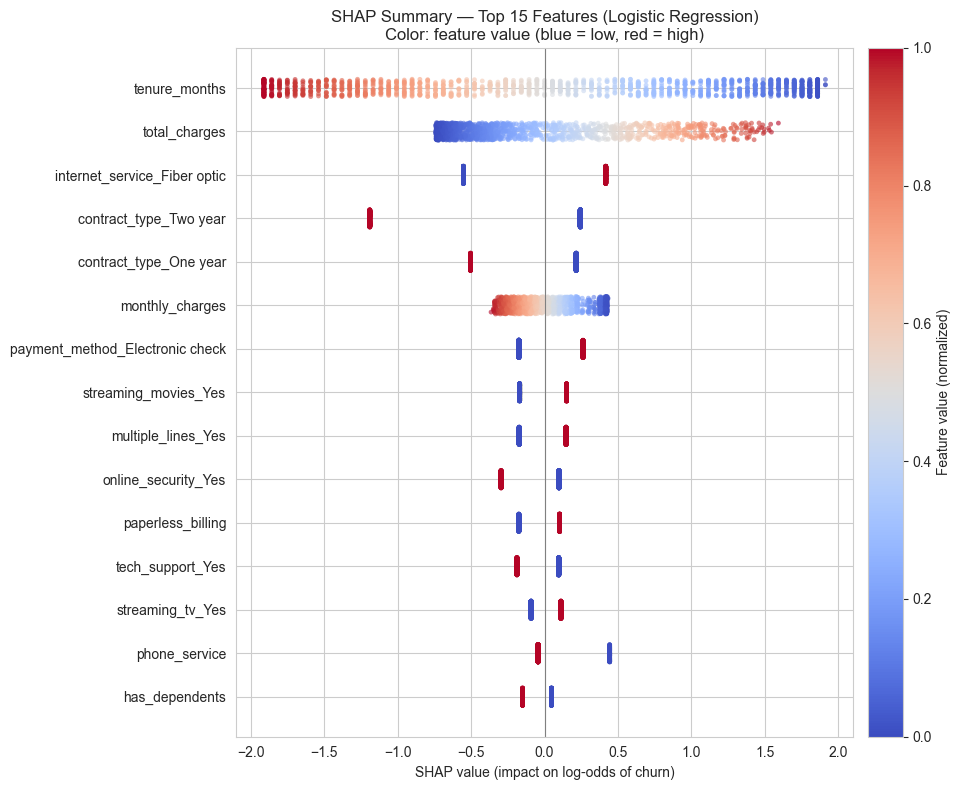

In [28]:
# Manual beeswarm-style plot that avoids SHAP's incompatible internals.
# Builds a similar visualization using only matplotlib + numpy.

import matplotlib.pyplot as plt
import numpy as np

# Coerce both SHAP values and features to clean float arrays
shap_np = np.asarray(shap_values, dtype=np.float64)
X_np    = X_test_scaled.to_numpy().astype(np.float64)
feature_names = X_test_scaled.columns.tolist()

# Rank features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_np).mean(axis=0)
top_n = 15
top_idx = np.argsort(mean_abs_shap)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 8))

for plot_row, feat_idx in enumerate(top_idx):
    y_pos = top_n - plot_row  # plot top feature at top of chart
    feat_vals  = X_np[:, feat_idx]
    shap_vals  = shap_np[:, feat_idx]

    # Normalize feature values to [0,1] for the color scale
    if feat_vals.max() != feat_vals.min():
        normed = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min())
    else:
        normed = np.zeros_like(feat_vals)

    # Add a tiny vertical jitter so points don't all stack on one line
    jitter = (np.random.rand(len(shap_vals)) - 0.5) * 0.4

    ax.scatter(shap_vals, np.full_like(shap_vals, y_pos) + jitter,
               c=normed, cmap='coolwarm', alpha=0.6, s=12, edgecolors='none')

ax.set_yticks(range(top_n, 0, -1))
ax.set_yticklabels([feature_names[i] for i in top_idx])
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on log-odds of churn)')
ax.set_title('SHAP Summary — Top 15 Features (Logistic Regression)\nColor: feature value (blue = low, red = high)')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=0, vmax=1))
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Feature value (normalized)')

plt.tight_layout()
plt.show()

Customer index: 1090
Predicted churn probability: 94.1%
Actual outcome: Churned



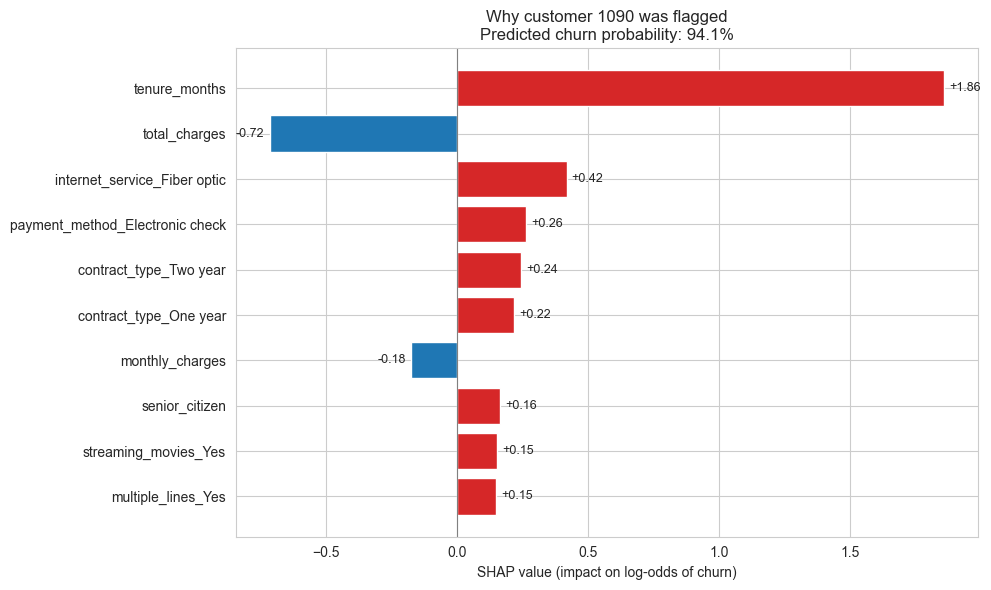

In [30]:
# Waterfall-style explanation: top features driving one high-risk customer's prediction
high_risk_idx = int(np.argmax(y_proba_lr))
print(f"Customer index: {high_risk_idx}")
print(f"Predicted churn probability: {y_proba_lr[high_risk_idx]:.1%}")
print(f"Actual outcome: {'Churned' if y_test.iloc[high_risk_idx] else 'Retained'}")
print()

shap_one = np.asarray(shap_values[high_risk_idx], dtype=np.float64)
feature_names = X_test_scaled.columns.tolist()

# Sort features by absolute contribution
order = np.argsort(np.abs(shap_one))[::-1]
top_n = 10
top_features = order[:top_n]

# Plot as horizontal bar chart, color-coded by sign
fig, ax = plt.subplots(figsize=(10, 6))

values   = shap_one[top_features]
labels   = [feature_names[i] for i in top_features]
colors   = ['#d62728' if v > 0 else '#1f77b4' for v in values]  # red=increases churn, blue=decreases

y_pos = np.arange(len(values))
ax.barh(y_pos, values, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  # most important at top
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on log-odds of churn)')
ax.set_title(f'Why customer {high_risk_idx} was flagged\n'
             f'Predicted churn probability: {y_proba_lr[high_risk_idx]:.1%}')

# Annotate each bar with its value
for i, v in enumerate(values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f'{v:+.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()